<a href="https://colab.research.google.com/github/shubhanagrawal/ML_MINI_PROJECT/blob/main/ML_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Imports and Environment Setup
import pandas as pd
import numpy as np
import requests # For NASA POWER API
import yfinance as yf # Reliable fallback for macro data
from pandas_datareader import data as pdr

# Time series and ML libraries (we will use these later)
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

# Set plotting style for later
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

print("Environment setup complete. Ready to build the pipeline.")

Environment setup complete. Ready to build the pipeline.


1. Loading local CPI data...
   ✅ CPI Data Loaded!
2. Fetching Macro Variables from FRED...
   ✅ FRED Data Loaded!
3. Generating RBI Repo Rate step-function...
   ✅ RBI Repo Rate Generated!
4. Fetching Climate Data from NASA POWER...
   ✅ Climate Anomalies Generated!

5. Compiling Master Dataset...
   ✅ Master Dataset Compiled! Shape: (132, 8)


,Food,Fuel,Misc,Brent_Crude,USD_INR,Repo_Rate,Rainfall_Anomaly,Temp_Anomaly
2014-01-01,9.66,6.35,6.45,107.926957,62.105714,8.0,-0.447880,0.564377
2014-02-01,8.16,6.04,6.23,108.838000,62.164211,8.0,2.245235,-0.566656
2014-03-01,8.61,6.03,6.30,107.868095,60.947619,8.0,1.626163,-1.771078
2014-04-01,9.19,5.63,6.39,108.003636,60.346364,8.0,-0.394923,0.104948
2014-05-01,8.88,4.75,6.68,109.832273,59.284286,8.0,0.073290,-0.185818


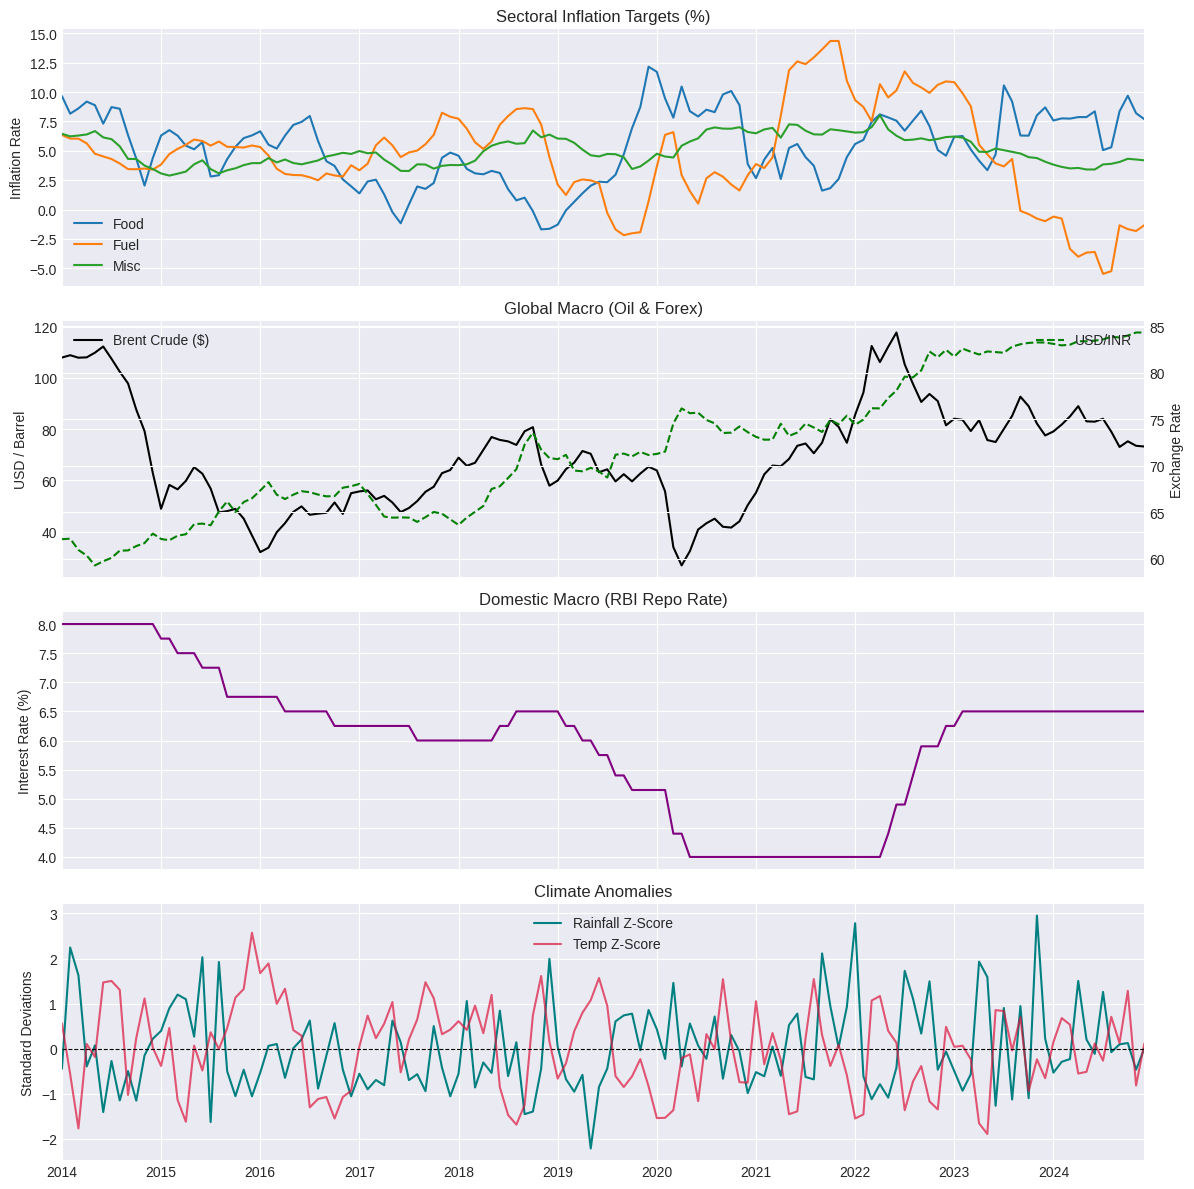

In [4]:
# Cell: The Complete Master Data Loader
import pandas as pd
import numpy as np
import requests
import datetime
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

class MacroDataLoader:
    def __init__(self, start_date='2014-01-01', end_date='2025-01-01'):
        self.start_date = start_date
        self.end_date = end_date
        self.raw_data = {}

    def load_local_cpi(self, filepath):
        """Loads and pivots local CPI data."""
        print("1. Loading local CPI data...")
        df = pd.read_csv(filepath)
        df['Month'] = pd.to_datetime(df['Month'], format='%b-%y')

        sector_mapping = {
            'A.1) Food and beverages': 'Food',
            'A.5) Fuel and light': 'Fuel',
            'A.6) Miscellaneous': 'Misc'
        }

        df_filtered = df[df['Commodity Description'].isin(sector_mapping.keys())].copy()
        df_filtered['Sector'] = df_filtered['Commodity Description'].map(sector_mapping)

        ts_df = df_filtered.pivot(index='Month', columns='Sector', values='Combined Inflation')
        ts_df = ts_df.sort_index().resample('MS').mean()
        ts_df = ts_df.loc[self.start_date:self.end_date]

        self.raw_data['CPI'] = ts_df
        print("   ✅ CPI Data Loaded!")
        return ts_df

    def fetch_fred_macro(self):
        """Fetches Brent Crude and USD/INR from FRED."""
        print("2. Fetching Macro Variables from FRED...")
        series_dict = {'Brent_Crude': 'POILBREUSDM', 'USD_INR': 'DEXINUS'}
        try:
            df_fred = web.DataReader(list(series_dict.values()), 'fred', self.start_date, self.end_date)
            df_fred.columns = list(series_dict.keys())
            df_fred = df_fred.resample('MS').mean()
            df_fred.fillna(method='ffill', inplace=True)
            self.raw_data['FRED'] = df_fred
            print("   ✅ FRED Data Loaded!")
            return df_fred
        except Exception as e:
            print(f"   ❌ Error fetching FRED: {e}")
            return None

    def fetch_rbi_repo(self):
        """Generates historical RBI Repo Rate."""
        print("3. Generating RBI Repo Rate step-function...")
        repo_changes = {
            '2013-01-01': 8.00, '2013-05-01': 7.25, '2013-09-01': 7.50, '2014-01-01': 8.00,
            '2015-01-01': 7.75, '2015-03-01': 7.50, '2015-06-01': 7.25, '2015-09-01': 6.75,
            '2016-04-01': 6.50, '2016-10-01': 6.25, '2017-08-01': 6.00, '2018-06-01': 6.25,
            '2018-08-01': 6.50, '2019-02-01': 6.25, '2019-04-01': 6.00, '2019-06-01': 5.75,
            '2019-08-01': 5.40, '2019-10-01': 5.15, '2020-03-01': 4.40, '2020-05-01': 4.00,
            '2022-05-01': 4.40, '2022-06-01': 4.90, '2022-08-01': 5.40, '2022-09-01': 5.90,
            '2022-12-01': 6.25, '2023-02-01': 6.50, '2025-01-01': 6.50
        }
        dates = pd.date_range(start=self.start_date, end=self.end_date, freq='D')
        repo_df = pd.DataFrame(index=dates, columns=['Repo_Rate'])

        for date_str, rate in repo_changes.items():
            if pd.to_datetime(date_str) in repo_df.index:
                repo_df.loc[pd.to_datetime(date_str), 'Repo_Rate'] = rate

        repo_df['Repo_Rate'] = repo_df['Repo_Rate'].ffill()
        repo_monthly = repo_df.resample('MS').mean()
        repo_monthly['Repo_Rate'] = repo_monthly['Repo_Rate'].bfill()

        self.raw_data['RBI'] = repo_monthly
        print("   ✅ RBI Repo Rate Generated!")
        return repo_monthly

    def fetch_nasa_climate(self, lat=20.5937, lon=78.9629):
        """Fetches NASA climate data and calculates dual anomalies."""
        print("4. Fetching Climate Data from NASA POWER...")
        start_year = pd.to_datetime(self.start_date).year
        end_year = pd.to_datetime(self.end_date).year

        url = (
            f"https://power.larc.nasa.gov/api/temporal/monthly/point?"
            f"parameters=PRECTOTCORR,T2M&community=RE&longitude={lon}&latitude={lat}"
            f"&start={start_year}&end={end_year}&format=JSON"
        )
        try:
            response = requests.get(url, verify=False)
            response.raise_for_status()
            data = response.json()

            climate_df = pd.DataFrame({
                'Precipitation': data['properties']['parameter']['PRECTOTCORR'],
                'Temperature': data['properties']['parameter']['T2M']
            })

            climate_df = climate_df[~climate_df.index.str.endswith('13')]
            climate_df.index = pd.to_datetime(climate_df.index, format='%Y%m')
            climate_df = climate_df.replace(-999.0, np.nan).ffill()

            # Anomalies
            climate_df['Month_Num'] = climate_df.index.month
            monthly_stats = climate_df.groupby('Month_Num').agg(['mean', 'std'])

            def calc_zscore(row, col):
                m = int(row['Month_Num'])
                val = row[col]
                mean = monthly_stats.loc[m, (col, 'mean')]
                std = monthly_stats.loc[m, (col, 'std')]
                return (val - mean) / std if std > 0 else 0

            climate_df['Rainfall_Anomaly'] = climate_df.apply(lambda x: calc_zscore(x, 'Precipitation'), axis=1)
            climate_df['Temp_Anomaly'] = climate_df.apply(lambda x: calc_zscore(x, 'Temperature'), axis=1)

            climate_df.drop(columns=['Month_Num', 'Precipitation', 'Temperature'], inplace=True)
            climate_df = climate_df.loc[self.start_date:self.end_date]

            self.raw_data['Climate'] = climate_df
            print("   ✅ Climate Anomalies Generated!")
            return climate_df
        except Exception as e:
            print(f"   ❌ Error fetching NASA data: {e}")
            return None

    def compile_master_dataset(self):
        """Merges all dataframes into a single master time-series matrix."""
        print("\n5. Compiling Master Dataset...")

        # Concatenate all dataframes along the columns (axis=1)
        # Because we strictly enforced Month-Start ('MS') frequency on all of them,
        # pandas will perfectly align them by their DatetimeIndex.
        master_df = pd.concat([
            self.raw_data['CPI'],
            self.raw_data['FRED'],
            self.raw_data['RBI'],
            self.raw_data['Climate']
        ], axis=1)

        # Handle the tiny edge cases where FRED might not have updated the latest month yet
        master_df.fillna(method='ffill', inplace=True)

        # Drop any remaining NaNs (usually caused by API boundary edge cases at the very start)
        master_df.dropna(inplace=True)

        print(f"   ✅ Master Dataset Compiled! Shape: {master_df.shape}")
        return master_df

# ==========================================
# Execution & Testing Block
# ==========================================

# 1. Instantiate the Pipeline
loader = MacroDataLoader(start_date='2014-01-01', end_date='2024-12-01')

# 2. Fetch all components
cpi = loader.load_local_cpi('Inflation(13-25).csv')  # Make sure file is uploaded in Colab
fred = loader.fetch_fred_macro()
rbi = loader.fetch_rbi_repo()
climate = loader.fetch_nasa_climate()

# 3. Compile Master Dataset
master_df = loader.compile_master_dataset()

# 4. Display the ultimate ML-ready dataset
display(master_df.head())

# 5. Visualize the finalized variables
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# Plot Targets
master_df[['Food', 'Fuel', 'Misc']].plot(ax=axes[0], title='Sectoral Inflation Targets (%)')
axes[0].set_ylabel('Inflation Rate')

# Plot FRED Macro
master_df['Brent_Crude'].plot(ax=axes[1], color='black', label='Brent Crude ($)')
axes[1].set_ylabel('USD / Barrel')
axes[1].legend(loc='upper left')
ax_twin = axes[1].twinx()
master_df['USD_INR'].plot(ax=ax_twin, color='green', label='USD/INR', linestyle='--')
ax_twin.set_ylabel('Exchange Rate')
ax_twin.legend(loc='upper right')
axes[1].set_title('Global Macro (Oil & Forex)')

# Plot Repo Rate
master_df['Repo_Rate'].plot(ax=axes[2], color='purple', title='Domestic Macro (RBI Repo Rate)')
axes[2].set_ylabel('Interest Rate (%)')

# Plot Climate
master_df['Rainfall_Anomaly'].plot(ax=axes[3], color='teal', label='Rainfall Z-Score')
master_df['Temp_Anomaly'].plot(ax=axes[3], color='crimson', label='Temp Z-Score', alpha=0.7)
axes[3].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[3].set_title('Climate Anomalies')
axes[3].set_ylabel('Standard Deviations')
axes[3].legend()

plt.tight_layout()
plt.show()

In [5]:
# Cell 6: Time-Series Feature Engineering
from statsmodels.tsa.stattools import adfuller

class TimeFeatureEngineer:
    def __init__(self, df, max_lags=3):
        """
        Takes the compiled master dataframe and prepares it for ML.
        max_lags: How many months back the model should look (e.g., 3 months).
        """
        self.df = df.copy()
        self.max_lags = max_lags

    def check_stationarity(self, series, name, alpha=0.05):
        """Runs the Augmented Dickey-Fuller test for stationarity."""
        result = adfuller(series.dropna())
        p_value = result[1]
        is_stationary = p_value < alpha
        print(f"ADF Test for {name}: p-value = {p_value:.4f} -> {'Stationary' if is_stationary else 'Non-Stationary'}")
        return is_stationary

    def build_sector_ml_matrix(self, target_sector):
        """
        Transforms the dataset into a supervised learning format for a specific sector.
        Equation: y_t = f(y_{t-1}, ..., y_{t-p}, X_{t-1}, ..., X_{t-q})
        """
        print(f"\n--- Building ML Matrix for Sector: {target_sector} ---")

        # Define our variables
        target = self.df[target_sector]
        # Exogenous variables are everything except the 3 CPI targets
        exo_cols = [col for col in self.df.columns if col not in ['Food', 'Fuel', 'Misc']]

        # 1. Check stationarity of the target (Informational)
        self.check_stationarity(target, target_sector)

        ml_df = pd.DataFrame(index=self.df.index)

        # 2. Add the Target Variable (What we want to predict)
        ml_df['Target'] = target

        # 3. Create Autoregressive Lags (Target at t-1, t-2, t-3)
        for i in range(1, self.max_lags + 1):
            ml_df[f'Lag_{i}_{target_sector}'] = target.shift(i)

        # 4. Create Exogenous Lags (Macro & Climate at t-1, t-2, t-3)
        # CRITICAL: We DO NOT include exogenous variables at time 't' to prevent data leakage.
        # We only let the model look at past macro conditions to predict current inflation.
        for col in exo_cols:
            for i in range(1, self.max_lags + 1):
                ml_df[f'Lag_{i}_{col}'] = self.df[col].shift(i)

        # 5. Drop the NaN rows created by shifting (the first 'max_lags' months)
        ml_df.dropna(inplace=True)

        print(f"✅ Matrix built! Shape: {ml_df.shape} (Features: {ml_df.shape[1] - 1})")
        return ml_df

# ==========================================
# Execution Block
# ==========================================

# Instantiate the Engineer looking 3 months into the past (p=3, q=3)
engineer = TimeFeatureEngineer(master_df, max_lags=3)

# Build the specific training matrix for the "Food" sector
food_ml_data = engineer.build_sector_ml_matrix('Food')
fuel_ml_data = engineer.build_sector_ml_matrix('Fuel')

# Let's inspect the columns for the Food sector to ensure no leakage
display(food_ml_data.head())


--- Building ML Matrix for Sector: Food ---
ADF Test for Food: p-value = 0.3285 -> Non-Stationary
✅ Matrix built! Shape: (129, 19) (Features: 18)

--- Building ML Matrix for Sector: Fuel ---
ADF Test for Fuel: p-value = 0.2839 -> Non-Stationary
✅ Matrix built! Shape: (129, 19) (Features: 18)


,Target,Lag_1_Food,Lag_2_Food,Lag_3_Food,Lag_1_Brent_Crude,Lag_2_Brent_Crude,Lag_3_Brent_Crude,Lag_1_USD_INR,Lag_2_USD_INR,Lag_3_USD_INR,Lag_1_Repo_Rate,Lag_2_Repo_Rate,Lag_3_Repo_Rate,Lag_1_Rainfall_Anomaly,Lag_2_Rainfall_Anomaly,Lag_3_Rainfall_Anomaly,Lag_1_Temp_Anomaly,Lag_2_Temp_Anomaly,Lag_3_Temp_Anomaly
2014-04-01,9.19,8.61,8.16,9.66,107.868095,108.838000,107.926957,60.947619,62.164211,62.105714,8.0,8.0,8.0,1.626163,2.245235,-0.447880,-1.771078,-0.566656,0.564377
2014-05-01,8.88,9.19,8.61,8.16,108.003636,107.868095,108.838000,60.346364,60.947619,62.164211,8.0,8.0,8.0,-0.394923,1.626163,2.245235,0.104948,-1.771078,-0.566656
2014-06-01,7.31,8.88,9.19,8.61,109.832273,108.003636,107.868095,59.284286,60.346364,60.947619,8.0,8.0,8.0,0.073290,-0.394923,1.626163,-0.185818,0.104948,-1.771078
2014-07-01,8.72,7.31,8.88,9.19,112.240952,109.832273,108.003636,59.736667,59.284286,60.346364,8.0,8.0,8.0,-1.407990,0.073290,-0.394923,1.469517,-0.185818,0.104948
2014-08-01,8.58,8.72,7.31,8.88,107.462609,112.240952,109.832273,60.095591,59.736667,59.284286,8.0,8.0,8.0,-0.273933,-1.407990,0.073290,1.502679,1.469517,-0.185818


--- Preparing 3D Tensor Data for Food LSTM ---
✅ 3D Train Tensor Shape: (102, 6, 6) (Samples, Time Steps, Features)
✅ 3D Test Tensor Shape: (24, 6, 6)

--- Building and Training LSTM Architecture ---
✅ LSTM Training Complete!

--- Evaluating LSTM Performance ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
LSTM RMSE: 4.371
LSTM MAE: 3.980


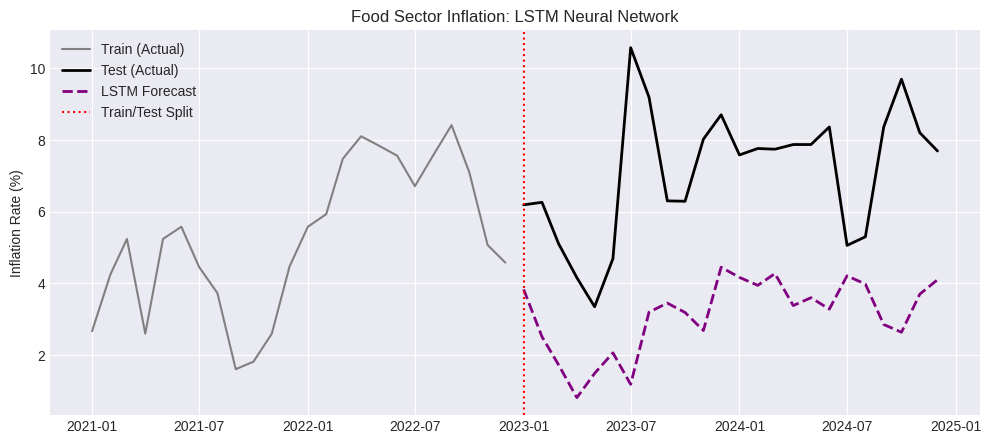

In [6]:
# Cell 8: LSTM Deep Learning Pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Import Deep Learning libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

class LSTMPipeline:
    def __init__(self, master_df, target_sector, time_steps=6, test_start_date='2023-01-01'):
        self.master_df = master_df.copy()
        self.target_sector = target_sector
        self.time_steps = time_steps
        self.test_start_date = pd.to_datetime(test_start_date)

        # We need two scalers: one for features, one for the target (to inverse transform later)
        self.feature_scaler = MinMaxScaler()
        self.target_scaler = MinMaxScaler()

    def prepare_3d_data(self):
        print(f"--- Preparing 3D Tensor Data for {self.target_sector} LSTM ---")

        # 1. Define Features (X) and Target (y)
        # For LSTM, we feed the historical Target IN as a feature too!
        feature_cols = [col for col in self.master_df.columns if col not in ['Food', 'Fuel', 'Misc']] + [self.target_sector]

        df_features = self.master_df[feature_cols]
        df_target = self.master_df[[self.target_sector]] # Keep as DataFrame for scaler

        # 2. Strict Train/Test Split BEFORE scaling to prevent Data Leakage
        train_mask = df_features.index < self.test_start_date
        test_mask = df_features.index >= self.test_start_date

        train_features = df_features[train_mask]
        test_features = df_features[test_mask]
        train_target = df_target[train_mask]

        # 3. Fit Scalers ONLY on Training Data
        self.feature_scaler.fit(train_features)
        self.target_scaler.fit(train_target)

        # 4. Transform entire dataset
        scaled_features = pd.DataFrame(self.feature_scaler.transform(df_features), index=df_features.index, columns=feature_cols)
        scaled_target = pd.DataFrame(self.target_scaler.transform(df_target), index=df_target.index, columns=[self.target_sector])

        # 5. Create 3D Sequences
        X, y, indices = [], [], []
        for i in range(len(scaled_features) - self.time_steps):
            # The window of features (t-6 to t-1)
            X.append(scaled_features.iloc[i : i + self.time_steps].values)
            # The target to predict (t)
            y.append(scaled_target.iloc[i + self.time_steps].values[0])
            # Keep track of the actual date we are predicting
            indices.append(scaled_target.index[i + self.time_steps])

        X, y = np.array(X), np.array(y)

        # 6. Split the created sequences into Train and Test
        # Find where the test set actually begins in the index list
        test_idx_start = next(i for i, date in enumerate(indices) if date >= self.test_start_date)

        self.X_train, self.X_test = X[:test_idx_start], X[test_idx_start:]
        self.y_train, self.y_test = y[:test_idx_start], y[test_idx_start:]
        self.train_dates, self.test_dates = indices[:test_idx_start], indices[test_idx_start:]

        print(f"✅ 3D Train Tensor Shape: {self.X_train.shape} (Samples, Time Steps, Features)")
        print(f"✅ 3D Test Tensor Shape: {self.X_test.shape}")

    def build_and_train_model(self):
        print("\n--- Building and Training LSTM Architecture ---")

        self.model = Sequential([
            # LSTM Layer: 64 neurons. input_shape = (Time_Steps, Features)
            LSTM(64, activation='relu', input_shape=(self.X_train.shape[1], self.X_train.shape[2])),

            # Dropout to prevent the neural network from memorizing the small dataset
            Dropout(0.2),

            # Dense output layer (1 neuron = predicting the single inflation value)
            Dense(1)
        ])

        self.model.compile(optimizer='adam', loss='mse')

        # EarlyStopping stops training when the validation loss stops improving
        early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

        history = self.model.fit(
            self.X_train, self.y_train,
            epochs=100,
            batch_size=8,
            validation_split=0.15,
            callbacks=[early_stop],
            verbose=0 # Set to 1 if you want to see the epochs count down
        )
        print("✅ LSTM Training Complete!")

    def evaluate_and_plot(self):
        print("\n--- Evaluating LSTM Performance ---")

        # Predict on Test Set
        scaled_preds = self.model.predict(self.X_test)

        # Inverse transform predictions and actuals back to normal Inflation % values
        self.preds = self.target_scaler.inverse_transform(scaled_preds).flatten()
        self.actuals = self.target_scaler.inverse_transform(self.y_test.reshape(-1, 1)).flatten()

        # Calculate Metrics
        rmse = np.sqrt(mean_squared_error(self.actuals, self.preds))
        mae = mean_absolute_error(self.actuals, self.preds)
        print(f"LSTM RMSE: {rmse:.3f}")
        print(f"LSTM MAE: {mae:.3f}")

        # Plotting
        plt.figure(figsize=(12, 5))

        # Plot the end of the training data for context
        hist_dates = self.train_dates[-24:]
        hist_actuals = self.target_scaler.inverse_transform(self.y_train[-24:].reshape(-1, 1)).flatten()
        plt.plot(hist_dates, hist_actuals, label='Train (Actual)', color='gray')

        # Plot Test Actuals vs Predictions
        plt.plot(self.test_dates, self.actuals, label='Test (Actual)', color='black', linewidth=2)
        plt.plot(self.test_dates, self.preds, label='LSTM Forecast', color='purple', linestyle='--', linewidth=2)

        plt.axvline(self.test_dates[0], color='red', linestyle=':', label='Train/Test Split')
        plt.title(f'{self.target_sector} Sector Inflation: LSTM Neural Network')
        plt.ylabel('Inflation Rate (%)')
        plt.legend()
        plt.show()

# ==========================================
# Execution Block
# ==========================================

# 1. Initialize the Deep Learning Pipeline (using 6 months of memory)
# Assuming 'master_df' is still in your notebook's memory
lstm_pipeline = LSTMPipeline(master_df=master_df, target_sector='Food', time_steps=6)

# 2. Execute the steps
lstm_pipeline.prepare_3d_data()
lstm_pipeline.build_and_train_model()
lstm_pipeline.evaluate_and_plot()

--- Preparing Differenced 3D Tensor Data for Food ---
✅ 3D Train Tensor Shape: (101, 6, 6)

--- Building and Training LSTM Architecture ---
✅ LSTM Training Complete!

--- Evaluating Differenced LSTM Performance ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Differenced LSTM RMSE: 2.475
Differenced LSTM MAE: 2.087


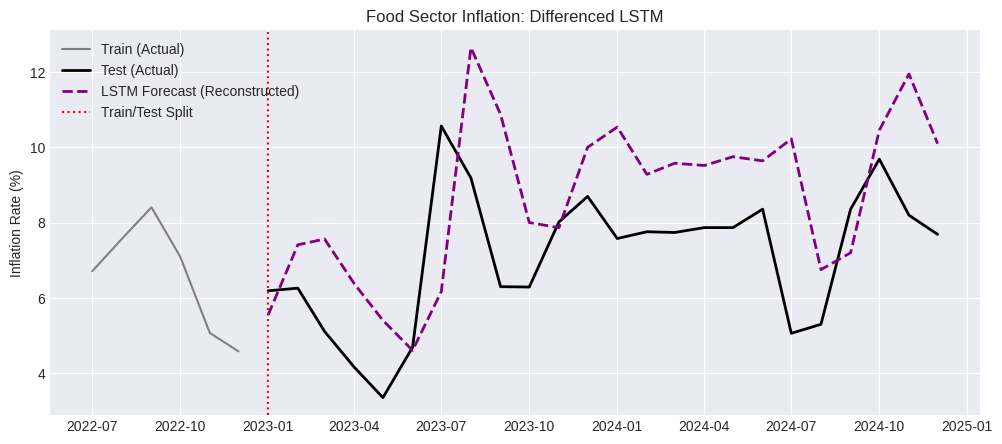

In [7]:
# Cell 9: Differenced LSTM Pipeline (Predicting Delta y)
class DifferencedLSTMPipeline(LSTMPipeline): # Inheriting to reuse plotting/building logic

    def prepare_3d_data(self):
        print(f"--- Preparing Differenced 3D Tensor Data for {self.target_sector} ---")

        # 1. Calculate the Month-over-Month Difference for the Target
        df = self.master_df.copy()
        target_diff_col = f'{self.target_sector}_Diff'
        df[target_diff_col] = df[self.target_sector].diff()

        # Drop the first row which is now NaN due to differencing
        df.dropna(inplace=True)
        self.working_df = df

        # 2. Features: Macro/Climate + The lagged DIFFERENCE (not absolute)
        feature_cols = [col for col in df.columns if col not in ['Food', 'Fuel', 'Misc', target_diff_col]] + [target_diff_col]

        df_features = df[feature_cols]
        df_target = df[[target_diff_col]]

        # 3. Train/Test Split
        train_mask = df_features.index < self.test_start_date
        test_mask = df_features.index >= self.test_start_date

        train_features = df_features[train_mask]
        test_features = df_features[test_mask]
        train_target = df_target[train_mask]

        # 4. Fit Scalers ONLY on Training Data
        self.feature_scaler.fit(train_features)
        self.target_scaler.fit(train_target)

        # 5. Transform dataset
        scaled_features = pd.DataFrame(self.feature_scaler.transform(df_features), index=df_features.index, columns=feature_cols)
        scaled_target = pd.DataFrame(self.target_scaler.transform(df_target), index=df_target.index, columns=[target_diff_col])

        # 6. Create 3D Sequences
        X, y, indices = [], [], []
        for i in range(len(scaled_features) - self.time_steps):
            X.append(scaled_features.iloc[i : i + self.time_steps].values)
            y.append(scaled_target.iloc[i + self.time_steps].values[0])
            indices.append(scaled_target.index[i + self.time_steps])

        X, y = np.array(X), np.array(y)

        test_idx_start = next(i for i, date in enumerate(indices) if date >= self.test_start_date)

        self.X_train, self.X_test = X[:test_idx_start], X[test_idx_start:]
        self.y_train, self.y_test = y[:test_idx_start], y[test_idx_start:]
        self.train_dates, self.test_dates = indices[:test_idx_start], indices[test_idx_start:]

        print(f"✅ 3D Train Tensor Shape: {self.X_train.shape}")

    def evaluate_and_plot(self):
        print("\n--- Evaluating Differenced LSTM Performance ---")

        # 1. Predict the DIFFERENCE (Delta y)
        scaled_diff_preds = self.model.predict(self.X_test)

        # 2. Inverse transform back to real % change values
        diff_preds = self.target_scaler.inverse_transform(scaled_diff_preds).flatten()
        diff_actuals = self.target_scaler.inverse_transform(self.y_test.reshape(-1, 1)).flatten()

        # 3. Reconstruct Absolute Inflation
        # To get prediction for month T, we take the ACTUAL inflation of month T-1 and add the PREDICTED difference
        reconstructed_preds = []
        reconstructed_actuals = []

        for i, date in enumerate(self.test_dates):
            # Find the actual inflation value from the previous month
            prev_month_idx = self.working_df.index.get_loc(date) - 1
            prev_actual_inflation = self.working_df[self.target_sector].iloc[prev_month_idx]

            # Reconstruct
            pred_inflation = prev_actual_inflation + diff_preds[i]
            actual_inflation = prev_actual_inflation + diff_actuals[i]

            reconstructed_preds.append(pred_inflation)
            reconstructed_actuals.append(actual_inflation)

        self.preds = np.array(reconstructed_preds)
        self.actuals = np.array(reconstructed_actuals)

        # Calculate Metrics on the Absolute values
        rmse = np.sqrt(mean_squared_error(self.actuals, self.preds))
        mae = mean_absolute_error(self.actuals, self.preds)
        print(f"Differenced LSTM RMSE: {rmse:.3f}")
        print(f"Differenced LSTM MAE: {mae:.3f}")

        # Plotting
        plt.figure(figsize=(12, 5))

        # Train context
        train_context_mask = (self.working_df.index < self.test_start_date) & (self.working_df.index >= self.working_df.index[-30])
        plt.plot(self.working_df.index[train_context_mask], self.working_df[self.target_sector][train_context_mask], label='Train (Actual)', color='gray')

        # Test actuals vs preds
        plt.plot(self.test_dates, self.actuals, label='Test (Actual)', color='black', linewidth=2)
        plt.plot(self.test_dates, self.preds, label='LSTM Forecast (Reconstructed)', color='purple', linestyle='--', linewidth=2)

        plt.axvline(self.test_dates[0], color='red', linestyle=':', label='Train/Test Split')
        plt.title(f'{self.target_sector} Sector Inflation: Differenced LSTM')
        plt.ylabel('Inflation Rate (%)')
        plt.legend()
        plt.show()

# ==========================================
# Execution Block
# ==========================================
# Initialize with time_steps=6
diff_pipeline = DifferencedLSTMPipeline(master_df=master_df, target_sector='Food', time_steps=6)

diff_pipeline.prepare_3d_data()
diff_pipeline.build_and_train_model()
diff_pipeline.evaluate_and_plot()

--- Running Permutation Feature Importance (The Scramble Test) ---
Baseline RMSE (Difference): 2.4751


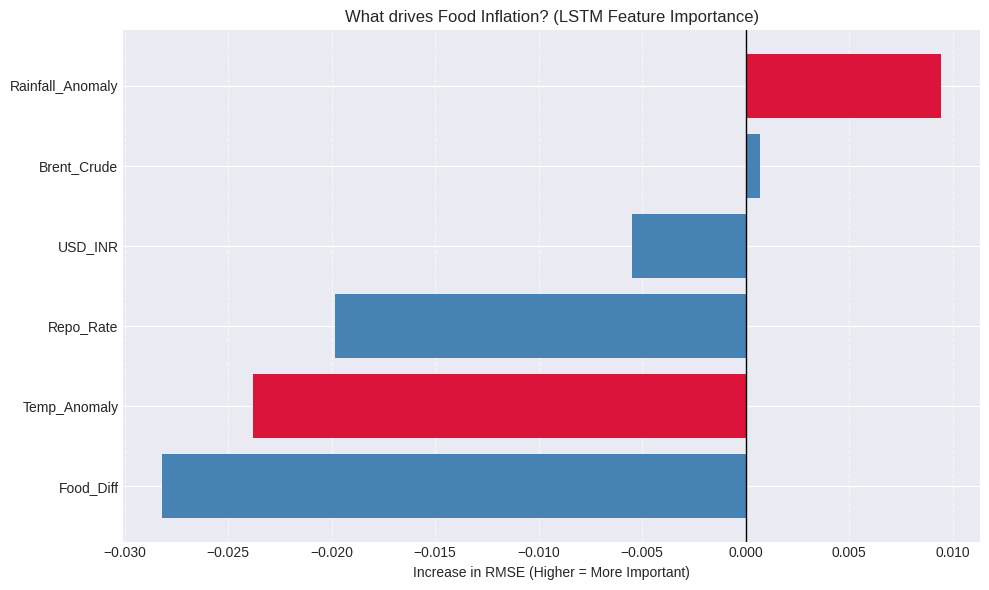

In [8]:
# Cell 10: LSTM Permutation Feature Importance
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def lstm_feature_importance(pipeline, n_repeats=5):
    print("--- Running Permutation Feature Importance (The Scramble Test) ---")

    # 1. Recreate the exact feature names used in the pipeline
    target_diff_col = f'{pipeline.target_sector}_Diff'
    feature_cols = [col for col in pipeline.working_df.columns
                    if col not in ['Food', 'Fuel', 'Misc', target_diff_col]] + [target_diff_col]

    # 2. Get the Baseline RMSE (Predicting Delta y)
    baseline_scaled_preds = pipeline.model.predict(pipeline.X_test, verbose=0)
    baseline_preds = pipeline.target_scaler.inverse_transform(baseline_scaled_preds).flatten()
    actuals = pipeline.target_scaler.inverse_transform(pipeline.y_test.reshape(-1, 1)).flatten()
    baseline_rmse = np.sqrt(mean_squared_error(actuals, baseline_preds))

    print(f"Baseline RMSE (Difference): {baseline_rmse:.4f}")

    importance_scores = {}

    # 3. Scramble each feature one by one
    for feature_idx, feature_name in enumerate(feature_cols):
        feature_scores = []

        for _ in range(n_repeats):
            # Create a fresh copy of the clean test data
            X_test_shuffled = pipeline.X_test.copy()

            # Scramble the specific feature across all samples
            # X_test shape is (Samples, Time_Steps, Features)
            np.random.shuffle(X_test_shuffled[:, :, feature_idx])

            # Predict with the corrupted data
            shuffled_scaled_preds = pipeline.model.predict(X_test_shuffled, verbose=0)
            shuffled_preds = pipeline.target_scaler.inverse_transform(shuffled_scaled_preds).flatten()

            # Calculate the new, worse RMSE
            shuffled_rmse = np.sqrt(mean_squared_error(actuals, shuffled_preds))
            feature_scores.append(shuffled_rmse)

        # The importance is how much WORSE the model got compared to the baseline
        # (Average corrupted RMSE - Baseline RMSE)
        importance_scores[feature_name] = np.mean(feature_scores) - baseline_rmse

    # 4. Sort and Plot the Results
    sorted_importance = dict(sorted(importance_scores.items(), key=lambda item: item[1]))

    plt.figure(figsize=(10, 6))
    colors = ['crimson' if 'Anomaly' in k else 'steelblue' for k in sorted_importance.keys()]

    plt.barh(list(sorted_importance.keys()), list(sorted_importance.values()), color=colors)
    plt.axvline(0, color='black', linewidth=1)
    plt.xlabel('Increase in RMSE (Higher = More Important)')
    plt.title(f'What drives {pipeline.target_sector} Inflation? (LSTM Feature Importance)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Execute the test on our highly successful Food model
lstm_feature_importance(diff_pipeline)

🌟 COMMENCING FINAL BATCH TRAINING 🌟

🚀 INITIALIZING PIPELINE FOR SECTOR: Fuel
--- Preparing Differenced 3D Tensor Data for Fuel ---
✅ 3D Train Tensor Shape: (101, 6, 6)

--- Building and Training LSTM Architecture ---
✅ LSTM Training Complete!

--- Evaluating Differenced LSTM Performance ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step
Differenced LSTM RMSE: 2.192
Differenced LSTM MAE: 1.828


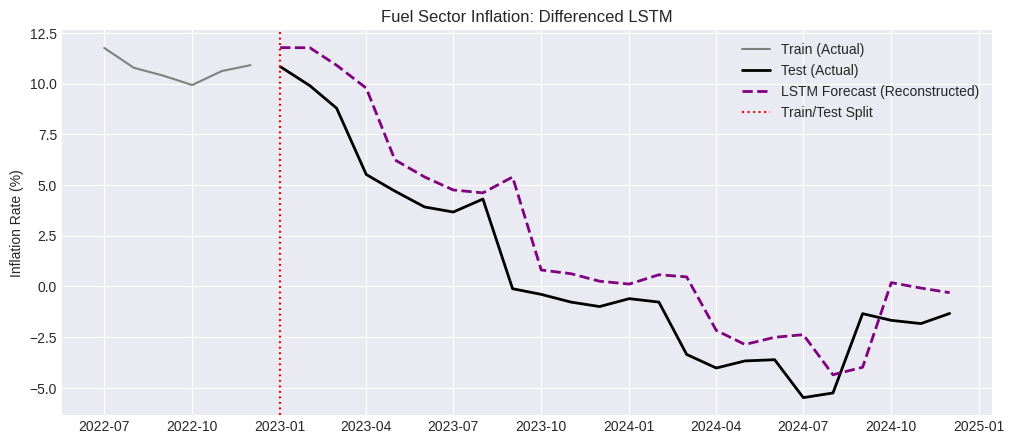


✅ Fuel Sector Pipeline Completed.

🚀 INITIALIZING PIPELINE FOR SECTOR: Misc
--- Preparing Differenced 3D Tensor Data for Misc ---
✅ 3D Train Tensor Shape: (101, 6, 6)

--- Building and Training LSTM Architecture ---
✅ LSTM Training Complete!

--- Evaluating Differenced LSTM Performance ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
Differenced LSTM RMSE: 0.289
Differenced LSTM MAE: 0.216


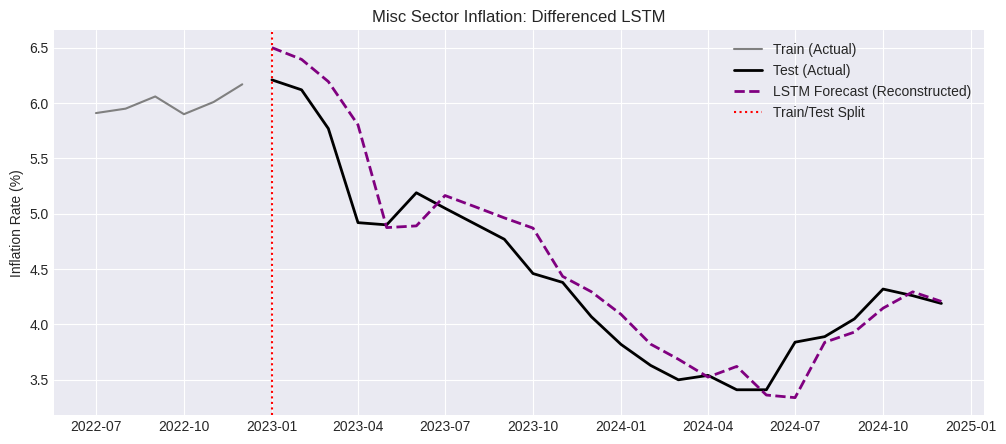


✅ Misc Sector Pipeline Completed.

🎉 ALL SECTORS SUCCESSFULLY MODELED! 🎉


In [9]:
# Cell 11: Scaling Pipeline to Fuel and Misc Sectors

# The sectors we have left to model
remaining_sectors = ['Fuel', 'Misc']

print("🌟 COMMENCING FINAL BATCH TRAINING 🌟\n")

for sector in remaining_sectors:
    print("="*60)
    print(f"🚀 INITIALIZING PIPELINE FOR SECTOR: {sector}")
    print("="*60)

    # 1. Initialize the pipeline for the specific sector
    sector_pipeline = DifferencedLSTMPipeline(
        master_df=master_df,
        target_sector=sector,
        time_steps=6
    )

    # 2. Run the architecture
    sector_pipeline.prepare_3d_data()
    sector_pipeline.build_and_train_model()

    # 3. Evaluate and display the visual results
    sector_pipeline.evaluate_and_plot()

    # Optional: Run feature importance for these too!
    # lstm_feature_importance(sector_pipeline, n_repeats=3)

    print(f"\n✅ {sector} Sector Pipeline Completed.\n")

print("🎉 ALL SECTORS SUCCESSFULLY MODELED! 🎉")


🔍 RUNNING SCRAMBLE TEST FOR: Fuel SECTOR
--- Running Permutation Feature Importance (The Scramble Test) ---
Baseline RMSE (Difference): 2.5122


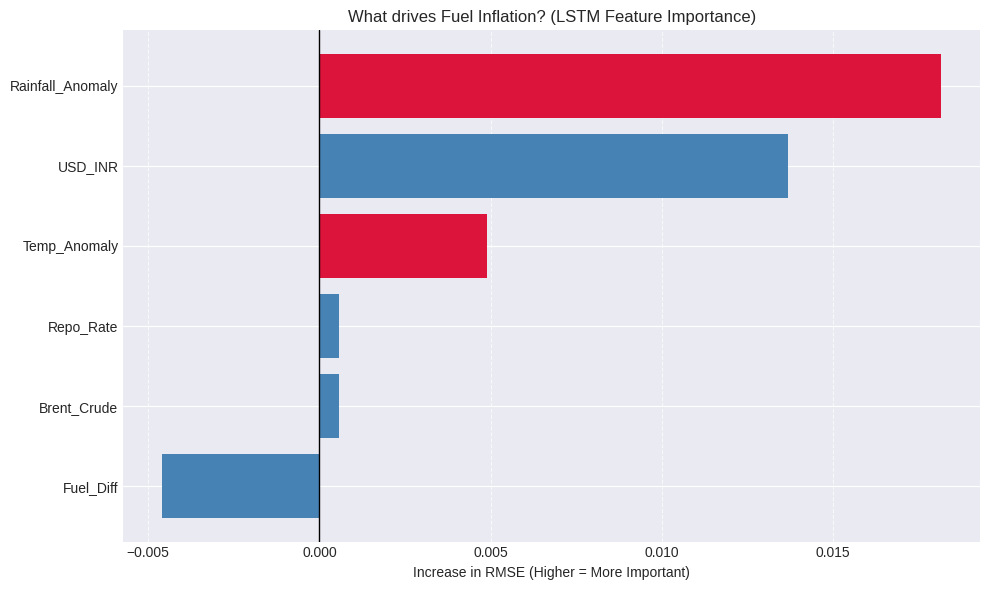


🔍 RUNNING SCRAMBLE TEST FOR: Misc SECTOR
--- Running Permutation Feature Importance (The Scramble Test) ---
Baseline RMSE (Difference): 0.2797


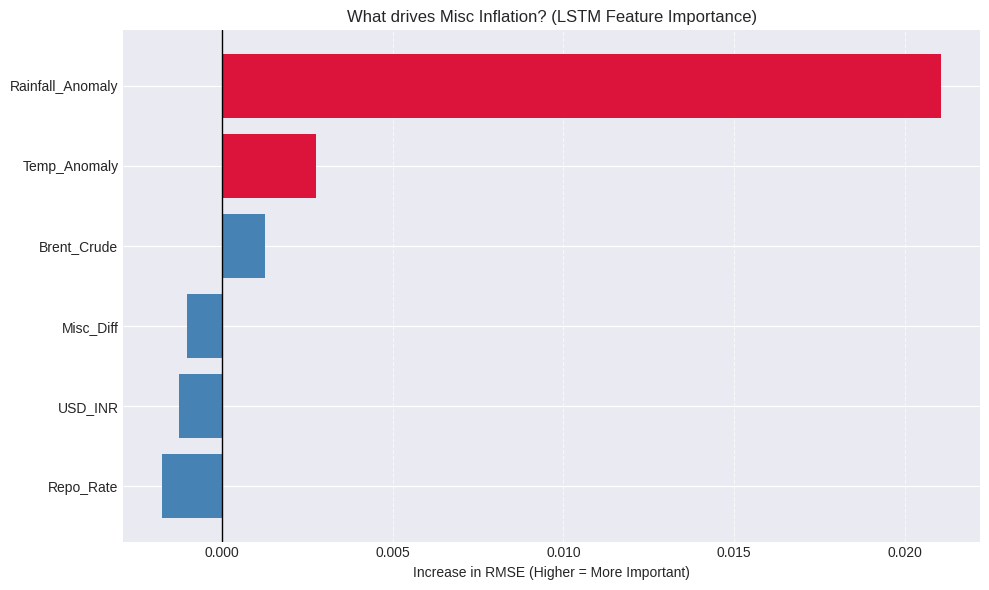

In [10]:
# Cell 12: Feature Importance for Fuel and Misc

sectors_to_interpret = ['Fuel', 'Misc']

for sector in sectors_to_interpret:
    print("\n" + "="*60)
    print(f"🔍 RUNNING SCRAMBLE TEST FOR: {sector} SECTOR")
    print("="*60)

    # 1. Initialize and train the pipeline quickly
    pipeline = DifferencedLSTMPipeline(
        master_df=master_df,
        target_sector=sector,
        time_steps=6
    )

    # Mute the prints for data prep to keep the output clean
    import sys, os
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')

    pipeline.prepare_3d_data()
    pipeline.build_and_train_model()

    sys.stdout.close()
    sys.stdout = old_stdout

    # 2. Run the feature importance function we defined earlier
    lstm_feature_importance(pipeline, n_repeats=5)

============== RUNNING PROPHET FOR FOOD ==============
Training Prophet Model...
✅ Prophet RMSE: 3.840 | MAE: 3.422


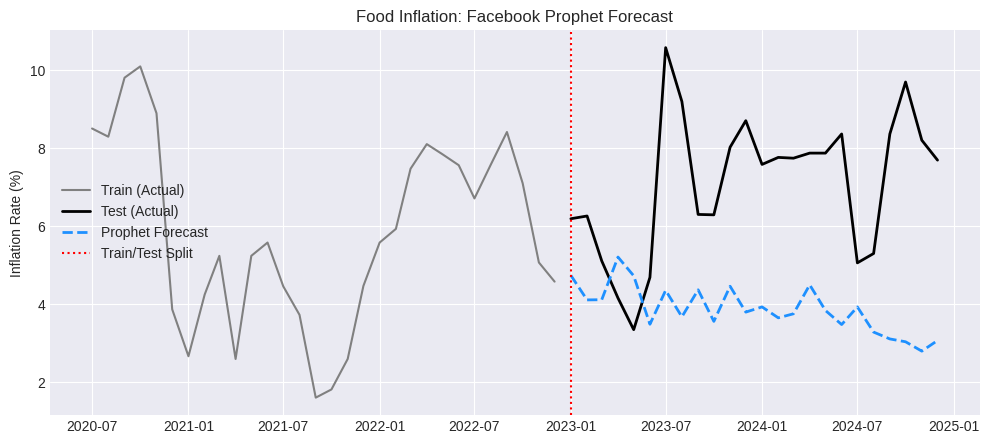

In [12]:
# Cell 17: Facebook Prophet Implementation
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

target_sector = 'Food' # Change this if you want to test Fuel or Misc
print(f"============== RUNNING PROPHET FOR {target_sector.upper()} ==============")

# 1. Prepare Prophet-friendly DataFrame
prophet_df = master_df.copy()
prophet_df = prophet_df.reset_index()
prophet_df = prophet_df.rename(columns={'index': 'ds', target_sector: 'y'}) # Renamed 'Month' to 'index'

# Define the external regressors (everything except the targets)
regressors = [col for col in prophet_df.columns if col not in ['ds', 'y', 'Food', 'Fuel', 'Misc']]

# 2. Strict Train/Test Split
test_start_date = pd.to_datetime('2023-01-01')
train_df = prophet_df[prophet_df['ds'] < test_start_date]
test_df = prophet_df[prophet_df['ds'] >= test_start_date]

# 3. Initialize and Train Prophet
# We lower seasonality_prior_scale to prevent overfitting on the small dataset
m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)

# Add all our macro and climate variables as external regressors
for reg in regressors:
    m.add_regressor(reg)

print("Training Prophet Model...")
m.fit(train_df)

# 4. Predict on Test Data
# Prophet needs the future dataframe to contain the future regressor values
future = test_df[['ds'] + regressors]
forecast = m.predict(future)

# 5. Evaluate and Plot
actuals = test_df['y'].values
preds = forecast['yhat'].values

rmse = np.sqrt(mean_squared_error(actuals, preds))
mae = mean_absolute_error(actuals, preds)
print(f"✅ Prophet RMSE: {rmse:.3f} | MAE: {mae:.3f}")

plt.figure(figsize=(12, 5))
# Plot Training Context
plt.plot(train_df['ds'][-30:], train_df['y'][-30:], label='Train (Actual)', color='gray')
# Plot Test Actuals vs Predictions
plt.plot(test_df['ds'], actuals, label='Test (Actual)', color='black', linewidth=2)
plt.plot(test_df['ds'], preds, label='Prophet Forecast', color='dodgerblue', linestyle='--', linewidth=2)

plt.axvline(test_start_date, color='red', linestyle=':', label='Train/Test Split')
plt.title(f'{target_sector} Inflation: Facebook Prophet Forecast')
plt.ylabel('Inflation Rate (%)')
plt.legend()
plt.show()

# Prophet Bonus: Plot the component breakdown (Trend vs Seasonality vs Regressors)
# fig_components = m.plot_components(forecast)


============== RUNNING DIFFERENCED XGBOOST FOR FOOD ==============
Training XGBoost Model...
✅ XGBoost RMSE: 4.287 | MAE: 3.717


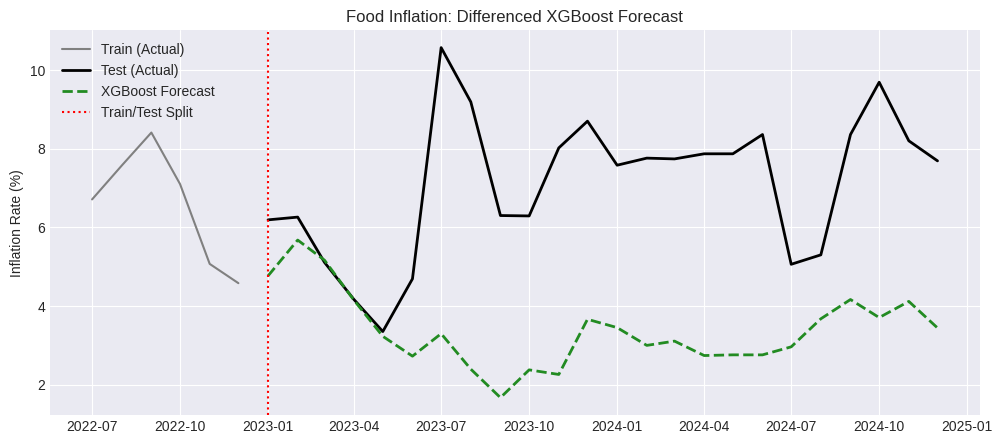

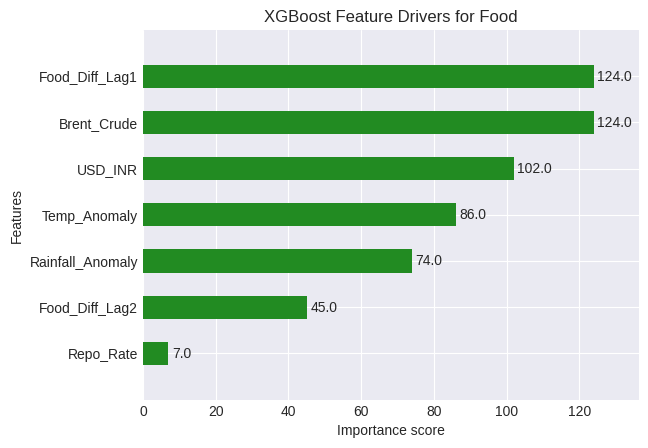

In [13]:
# Cell 18: Differenced XGBoost Implementation
import xgboost as xgb

print(f"\n============== RUNNING DIFFERENCED XGBOOST FOR {target_sector.upper()} ==============")

# 1. Prepare Differenced Data and Lags
xgb_df = master_df.copy()
target_diff_col = f'{target_sector}_Diff'

# Calculate the month-over-month difference
xgb_df[target_diff_col] = xgb_df[target_sector].diff()

# Engineer Lag Features (Give XGBoost a "memory" of the last 2 months)
xgb_df[f'{target_diff_col}_Lag1'] = xgb_df[target_diff_col].shift(1)
xgb_df[f'{target_diff_col}_Lag2'] = xgb_df[target_diff_col].shift(2)

# Drop NaN rows created by differencing and shifting
xgb_df.dropna(inplace=True)

# Define Features and Target
feature_cols = [col for col in xgb_df.columns if col not in ['Food', 'Fuel', 'Misc', target_diff_col, target_sector]]
X = xgb_df[feature_cols]
y = xgb_df[target_diff_col]

# 2. Strict Train/Test Split
train_mask = X.index < test_start_date
test_mask = X.index >= test_start_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# 3. Train XGBoost
# We use a very shallow tree (max_depth=3) to prevent overfitting on the small dataset
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
print("Training XGBoost Model...")
xgb_model.fit(X_train, y_train)

# 4. Predict the DIFFERENCE
diff_preds = xgb_model.predict(X_test)
diff_actuals = y_test.values

# 5. Recursive Reconstruction (True Out-of-Sample Forecast)
reconstructed_preds = []
reconstructed_actuals = []

# Anchor starts at the last actual value in the training set
current_pred_anchor = xgb_df[target_sector][xgb_df.index < test_start_date].iloc[-1]
test_dates = X_test.index

for i, date in enumerate(test_dates):
    # Model adds predicted diff to its OWN previous prediction
    pred_inflation = current_pred_anchor + diff_preds[i]
    reconstructed_preds.append(pred_inflation)
    current_pred_anchor = pred_inflation

    # Actuals
    prev_actual_inflation = xgb_df[target_sector].iloc[xgb_df.index.get_loc(date) - 1]
    actual_inflation = prev_actual_inflation + diff_actuals[i]
    reconstructed_actuals.append(actual_inflation)

preds = np.array(reconstructed_preds)
actuals = np.array(reconstructed_actuals)

rmse = np.sqrt(mean_squared_error(actuals, preds))
mae = mean_absolute_error(actuals, preds)
print(f"✅ XGBoost RMSE: {rmse:.3f} | MAE: {mae:.3f}")

# 6. Plotting
plt.figure(figsize=(12, 5))
train_context_mask = (xgb_df.index < test_start_date) & (xgb_df.index >= xgb_df.index[-30])
plt.plot(xgb_df.index[train_context_mask], xgb_df[target_sector][train_context_mask], label='Train (Actual)', color='gray')

plt.plot(test_dates, actuals, label='Test (Actual)', color='black', linewidth=2)
plt.plot(test_dates, preds, label='XGBoost Forecast', color='forestgreen', linestyle='--', linewidth=2)

plt.axvline(test_start_date, color='red', linestyle=':', label='Train/Test Split')
plt.title(f'{target_sector} Inflation: Differenced XGBoost Forecast')
plt.ylabel('Inflation Rate (%)')
plt.legend()
plt.show()

# XGBoost Feature Importance
xgb.plot_importance(xgb_model, max_num_features=10, height=0.5, color='forestgreen', title=f'XGBoost Feature Drivers for {target_sector}')
plt.show()


🥊 BATTLE: PROPHET vs DIFFERENCED XGBOOST -> FUEL SECTOR
🔵 Prophet RMSE: 10.226
🟢 XGBoost RMSE: 4.767
🏆 WINNER: XGBoost (Machine Learning)



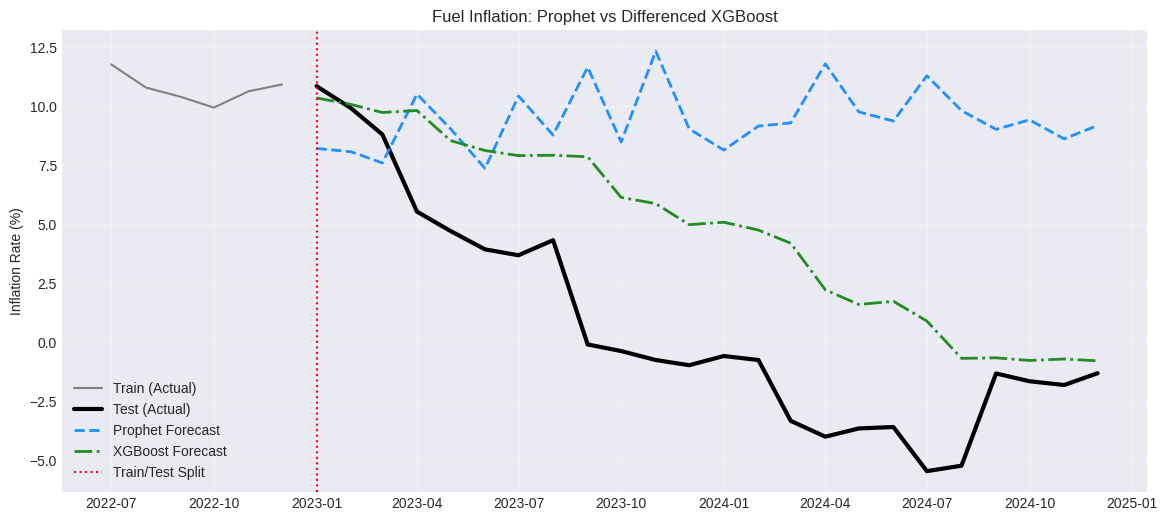


🥊 BATTLE: PROPHET vs DIFFERENCED XGBOOST -> MISC SECTOR
🔵 Prophet RMSE: 0.840
🟢 XGBoost RMSE: 3.724
🏆 WINNER: Prophet (Statistical)



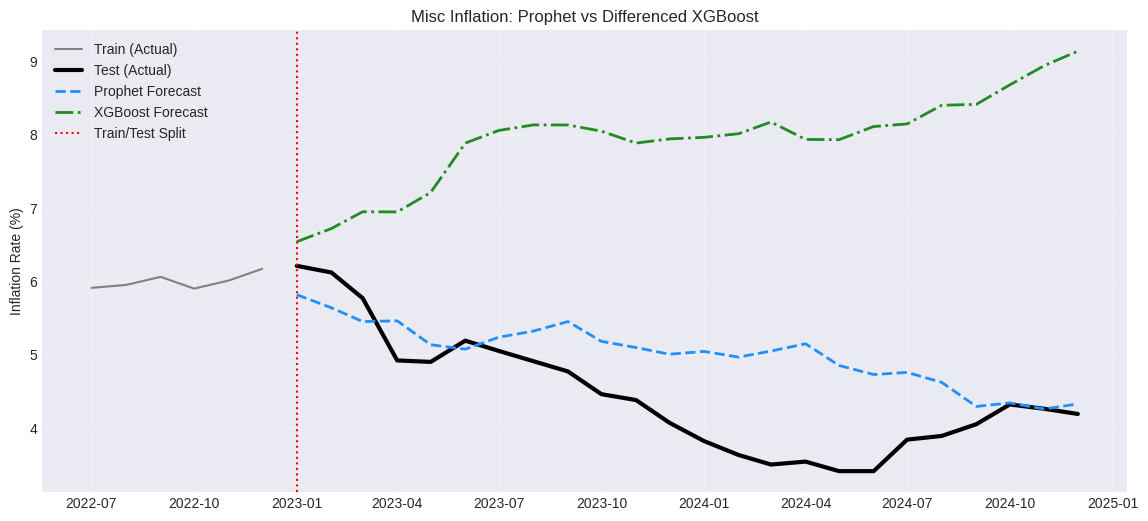

🎉 MULTI-SECTOR SHOWDOWN COMPLETE! 🎉


In [15]:
# Cell 19: The Final Showdown (Prophet vs XGBoost for Fuel & Misc)
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging

# Suppress Prophet's verbose C++ logs for a clean output
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

sectors_to_test = ['Fuel', 'Misc']
test_start_date = pd.to_datetime('2023-01-01')

for target_sector in sectors_to_test:
    print("\n" + "="*65)
    print(f"🥊 BATTLE: PROPHET vs DIFFERENCED XGBOOST -> {target_sector.upper()} SECTOR")
    print("="*65)

    # ---------------------------------------------------------
    # 1. PROPHET PIPELINE (The Statistical Approach)
    # ---------------------------------------------------------
    prophet_df = master_df.copy().reset_index().rename(columns={'index': 'ds', target_sector: 'y'})
    regressors = [col for col in prophet_df.columns if col not in ['ds', 'y', 'Food', 'Fuel', 'Misc']]

    train_df_p = prophet_df[prophet_df['ds'] < test_start_date]
    test_df_p = prophet_df[prophet_df['ds'] >= test_start_date]

    m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    for reg in regressors:
        m.add_regressor(reg)

    m.fit(train_df_p)
    future = test_df_p[['ds'] + regressors]
    forecast = m.predict(future)

    prophet_preds = forecast['yhat'].values
    actuals = test_df_p['y'].values # The ground truth
    prophet_rmse = np.sqrt(mean_squared_error(actuals, prophet_preds))

    # ---------------------------------------------------------
    # 2. DIFFERENCED XGBOOST PIPELINE (The ML Approach)
    # ---------------------------------------------------------
    xgb_df = master_df.copy()
    target_diff_col = f'{target_sector}_Diff'
    xgb_df[target_diff_col] = xgb_df[target_sector].diff()
    xgb_df[f'{target_diff_col}_Lag1'] = xgb_df[target_diff_col].shift(1)
    xgb_df[f'{target_diff_col}_Lag2'] = xgb_df[target_diff_col].shift(2)
    xgb_df.dropna(inplace=True)

    feature_cols = [col for col in xgb_df.columns if col not in ['Food', 'Fuel', 'Misc', target_diff_col, target_sector]]
    X = xgb_df[feature_cols]
    y = xgb_df[target_diff_col]

    train_mask = X.index < test_start_date
    test_mask = X.index >= test_start_date
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    xgb_model.fit(X_train, y_train)
    diff_preds = xgb_model.predict(X_test)

    # Recursive Reconstruction
    reconstructed_preds = []
    current_pred_anchor = xgb_df[target_sector][xgb_df.index < test_start_date].iloc[-1]

    for i in range(len(X_test)):
        pred_inflation = current_pred_anchor + diff_preds[i]
        reconstructed_preds.append(pred_inflation)
        current_pred_anchor = pred_inflation

    xgb_preds = np.array(reconstructed_preds)
    xgb_rmse = np.sqrt(mean_squared_error(actuals, xgb_preds))

    # ---------------------------------------------------------
    # 3. SCOREBOARD & PLOTTING
    # ---------------------------------------------------------
    print(f"🔵 Prophet RMSE: {prophet_rmse:.3f}")
    print(f"🟢 XGBoost RMSE: {xgb_rmse:.3f}")
    winner = "Prophet (Statistical)" if prophet_rmse < xgb_rmse else "XGBoost (Machine Learning)"
    print(f"🏆 WINNER: {winner}\n")

    plt.figure(figsize=(14, 6))

    # Plot Training Context (Last 30 months)
    train_context_mask = (xgb_df.index < test_start_date) & (xgb_df.index >= xgb_df.index[-30])
    plt.plot(xgb_df.index[train_context_mask], xgb_df[target_sector][train_context_mask], label='Train (Actual)', color='gray')

    # Plot Test Data & Predictions
    plt.plot(test_df_p['ds'], actuals, label='Test (Actual)', color='black', linewidth=3)
    plt.plot(test_df_p['ds'], prophet_preds, label='Prophet Forecast', color='dodgerblue', linestyle='--', linewidth=2)
    plt.plot(test_df_p['ds'], xgb_preds, label='XGBoost Forecast', color='forestgreen', linestyle='-.', linewidth=2)

    plt.axvline(test_start_date, color='red', linestyle=':', label='Train/Test Split')
    plt.title(f'{target_sector} Inflation: Prophet vs Differenced XGBoost')
    plt.ylabel('Inflation Rate (%)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

print("🎉 MULTI-SECTOR SHOWDOWN COMPLETE! 🎉")

🔍 EXTRACTING ECONOMIC DRIVERS (XGBOOST FEATURE IMPORTANCE)


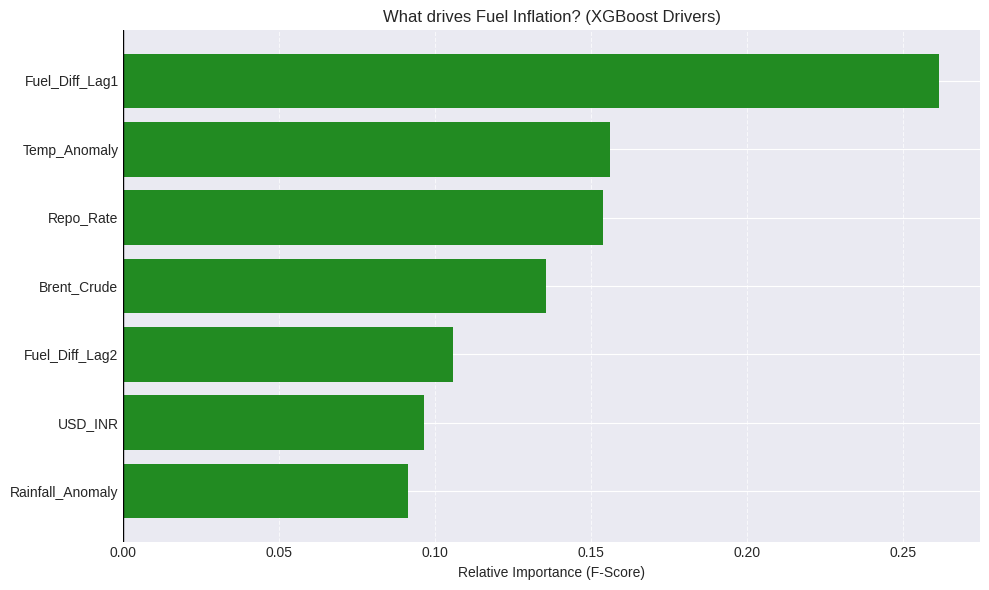

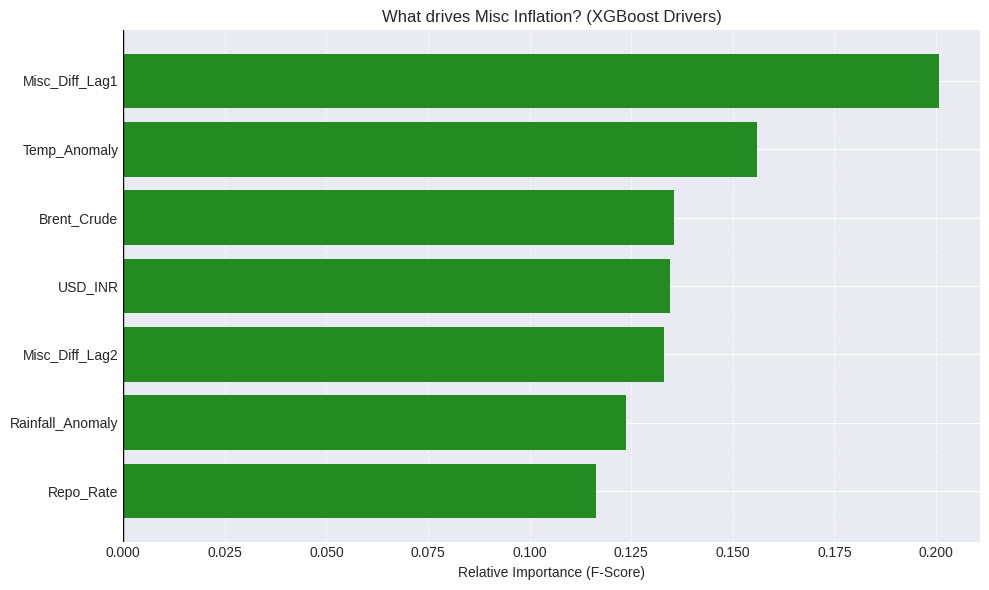

In [16]:
# Cell 20: XGBoost Feature Importance Extraction
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sectors_to_analyze = ['Fuel', 'Misc']
test_start_date = pd.to_datetime('2023-01-01')

print("="*65)
print("🔍 EXTRACTING ECONOMIC DRIVERS (XGBOOST FEATURE IMPORTANCE)")
print("="*65)

for target_sector in sectors_to_analyze:
    # 1. Prepare the data (Differenced + Lags)
    xgb_df = master_df.copy()
    target_diff_col = f'{target_sector}_Diff'
    xgb_df[target_diff_col] = xgb_df[target_sector].diff()
    xgb_df[f'{target_diff_col}_Lag1'] = xgb_df[target_diff_col].shift(1)
    xgb_df[f'{target_diff_col}_Lag2'] = xgb_df[target_diff_col].shift(2)
    xgb_df.dropna(inplace=True)

    # Isolate features
    feature_cols = [col for col in xgb_df.columns if col not in ['Food', 'Fuel', 'Misc', target_diff_col, target_sector]]
    X = xgb_df[feature_cols]
    y = xgb_df[target_diff_col]

    # 2. Train on the historical data
    train_mask = X.index < test_start_date
    X_train = X[train_mask]
    y_train = y[train_mask]

    xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    xgb_model.fit(X_train, y_train)

    # 3. Extract and Plot Feature Importances
    importances = xgb_model.feature_importances_
    importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})

    # Sort for a clean chart
    importance_df = importance_df.sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='forestgreen')
    plt.title(f'What drives {target_sector} Inflation? (XGBoost Drivers)')
    plt.xlabel('Relative Importance (F-Score)')
    plt.axvline(0, color='black', linewidth=1)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [18]:
def create_lag_features(df, cols, lags=[1,2,3,6,12]):
    df_copy = df.copy()

    for col in cols:
        for lag in lags:
            df_copy[f"{col}_lag_{lag}"] = df_copy[col].shift(lag)

    return df_copy

# Example usage
lag_columns = ['Brent_Crude', 'Fuel', 'Food'] # Adjusted column names to match master_df

df = create_lag_features(master_df.copy(), lag_columns)

# Drop NaNs created due to lagging
df = df.dropna().reset_index(drop=False) # Changed to drop=False to keep the datetime index

In [19]:
pip install shap

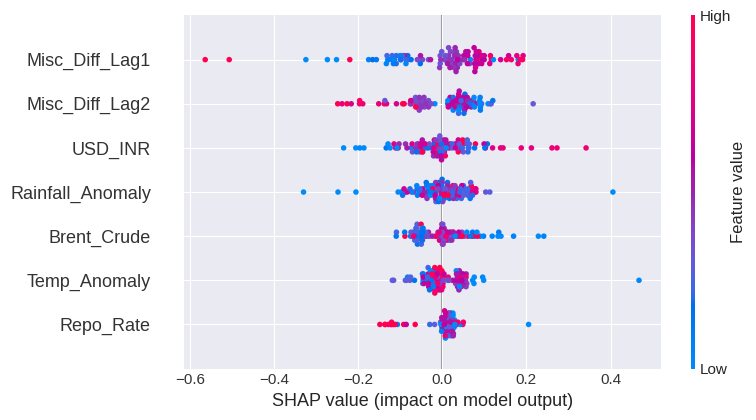

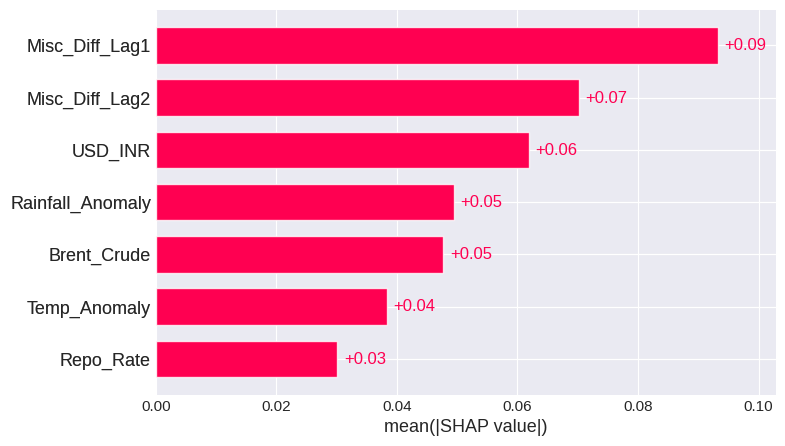

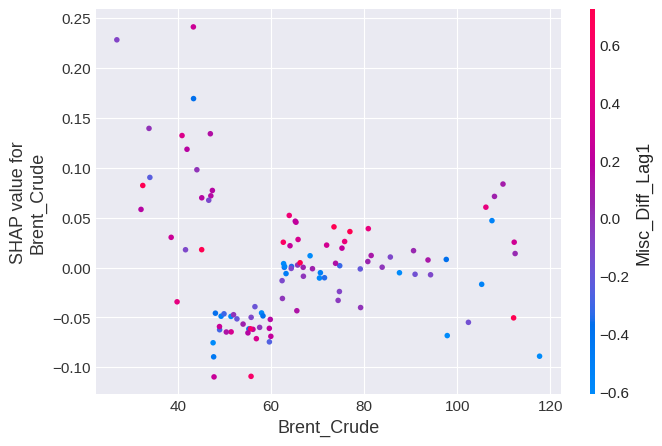

In [21]:
import shap

# The xgb_model is already trained from the previous cell (for the 'Misc' sector)
# We will use that pre-trained model for SHAP analysis.
# No need to call model.fit(X_train, y_train) again.

# Create explainer
explainer = shap.Explainer(xgb_model)

# Compute SHAP values
shap_values = explainer(X_train)

# Summary plot (global importance)
shap.summary_plot(shap_values, X_train)

# Feature impact (direction + magnitude)
shap.plots.bar(shap_values)

# Dependence plot (VERY IMPORTANT)
# Ensure 'Brent_Crude' is a valid feature name in X_train
shap.dependence_plot("Brent_Crude", shap_values.values, X_train)

In [25]:
def granger_summary(data, max_lag=6):
    from statsmodels.tsa.stattools import grangercausalitytests

    # grangercausalitytests expects the DataFrame to have the 'y' variable as the first column
    # and the 'x' variable(s) as subsequent columns.
    results = grangercausalitytests(data, maxlag=max_lag, verbose=False)

    summary = []

    # The results dictionary structure is a bit complex. The p-value for the F-test
    # for the null hypothesis that X does NOT Granger-cause Y is at results[lag][0]['ssr_ftest'][1]
    for lag in range(1, max_lag+1):
        # Check if the lag exists in the results before accessing
        if lag in results and results[lag] and 'ssr_ftest' in results[lag][0]:
            p_value = results[lag][0]['ssr_ftest'][1]
            summary.append((lag, p_value))
        else:
            summary.append((lag, None)) # Indicate that result not found for this lag

    return summary

# Example usage: Test if 'Brent_Crude' Granger-causes 'Misc' inflation
# Make sure the 'y' (dependent) variable is the first column
data_for_granger = master_df[['Food', 'Brent_Crude']]

print("Granger Causality Test Results (Food inflation vs Brent Crude):")
summary = granger_summary(data_for_granger, max_lag=6)

for lag, p in summary:
    if p is not None:
        print(f"Lag {lag}: p-value = {p:.4f} ({'Reject H0: Brent Crude causes Misc' if p < 0.05 else 'Fail to reject H0'})")
    else:
        print(f"Lag {lag}: No p-value found.")

Granger Causality Test Results (Food inflation vs Brent Crude):
Lag 1: p-value = 0.9465 (Fail to reject H0)
Lag 2: p-value = 0.3957 (Fail to reject H0)
Lag 3: p-value = 0.8233 (Fail to reject H0)
Lag 4: p-value = 0.9125 (Fail to reject H0)
Lag 5: p-value = 0.5540 (Fail to reject H0)
Lag 6: p-value = 0.5528 (Fail to reject H0)
